
**Step 0 – Setup & Upload Dataset**

In [5]:
from google.colab import files
uploaded = files.upload()

Saving global_air_quality_dataset.csv to global_air_quality_dataset (1).csv


In [7]:
import pandas as pd
df = pd.read_csv('global_air_quality_dataset.csv')
print("✅ Loaded successfully")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

✅ Loaded successfully
Rows: 3660, Columns: 13


,Date,City,Country,AQI,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (°C),Humidity (%),Wind Speed (m/s)
0,2024-01-01,New York,USA,38,120.0,182.9,24.3,26.0,9.10,153.3,18.6,40,13.2
1,2024-01-01,Los Angeles,USA,280,38.4,46.9,41.8,34.7,3.78,190.7,-2.2,59,9.5
2,2024-01-01,London,UK,117,168.1,34.3,81.5,8.2,3.67,105.4,36.3,62,3.4
3,2024-01-01,Beijing,China,197,96.8,35.4,18.5,39.4,9.51,92.8,29.9,32,1.8
4,2024-01-01,Delhi,India,187,76.2,226.8,46.9,17.2,1.02,68.4,9.9,55,3.3


**Part A – Data Loading and Understanding**

In [8]:
# 2. First 5 rows
df.head()

# 3. Number of rows and columns
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# 4. Column names
print(df.columns.tolist())

# 5. Data types
print(df.dtypes)

# 6. Missing values
print(df.isnull().sum())

# 7. Duplicate records
print(f"Duplicate rows: {df.duplicated().sum()}")

Rows: 3660, Columns: 13
['Date', 'City', 'Country', 'AQI', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (ppb)', 'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)']
Date                 object
City                 object
Country              object
AQI                   int64
PM2.5 (µg/m³)       float64
PM10 (µg/m³)        float64
NO2 (ppb)           float64
SO2 (ppb)           float64
CO (ppm)            float64
O3 (ppb)            float64
Temperature (°C)    float64
Humidity (%)          int64
Wind Speed (m/s)    float64
dtype: object
Date                0
City                0
Country             0
AQI                 0
PM2.5 (µg/m³)       0
PM10 (µg/m³)        0
NO2 (ppb)           0
SO2 (ppb)           0
CO (ppm)            0
O3 (ppb)            0
Temperature (°C)    0
Humidity (%)        0
Wind Speed (m/s)    0
dtype: int64
Duplicate rows: 0


**Part B – Data Cleaning**

In [9]:
# 9. Remove duplicates (if any)
df = df.drop_duplicates()

# 10. Handle missing values – none here, but we still ensure numeric columns are proper
# No missing values in this dataset. If there were, we would use median on numeric columns.

# 11. Convert date column
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# 12. Create year and month columns
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# 13. Remove unnecessary columns (optional – keep all for now)
# We'll keep all; no column is completely useless.

# 14. Ensure numeric columns are correct (they already are)
numeric_cols = ['AQI', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (ppb)', 'SO2 (ppb)',
                'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data cleaning completed")

Data cleaning completed


**Part C – Create AQI Categories**

In [10]:
def aqi_category(aqi):
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Moderate'
    elif aqi <= 150:
        return 'Unhealthy for Sensitive Groups'
    elif aqi <= 200:
        return 'Unhealthy'
    elif aqi <= 300:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

df['AQI Category'] = df['AQI'].apply(aqi_category)
print(df['AQI Category'].value_counts())

AQI Category
Very Unhealthy                    1360
Moderate                           673
Unhealthy                          666
Unhealthy for Sensitive Groups     664
Good                               297
Name: count, dtype: int64



**Part D – Exploratory Data Analysis (5 visualizations)**

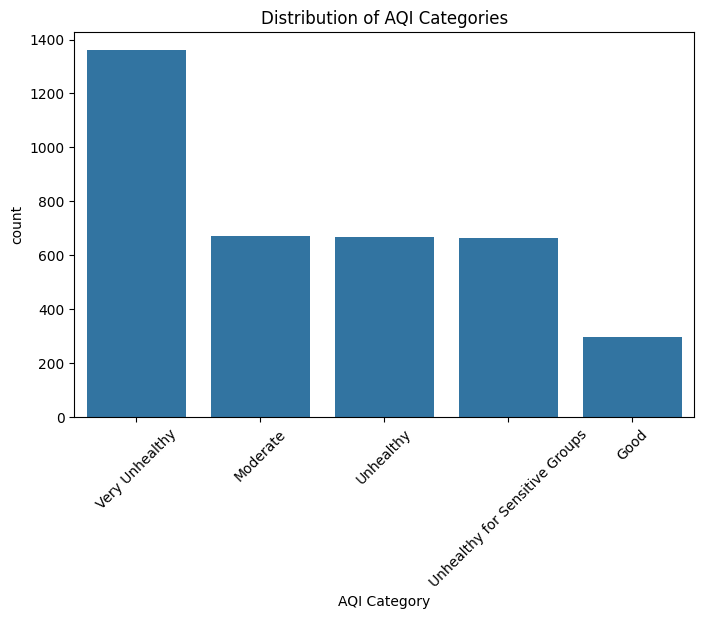

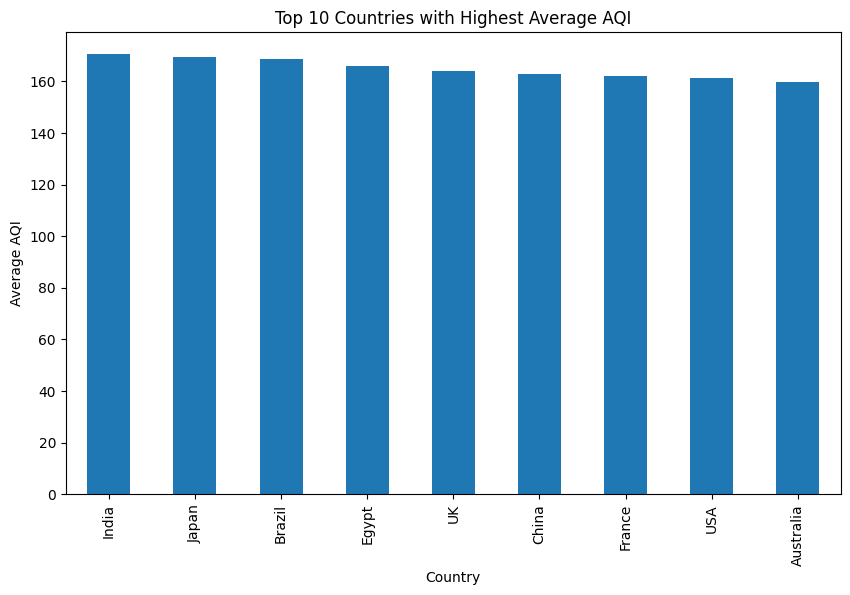

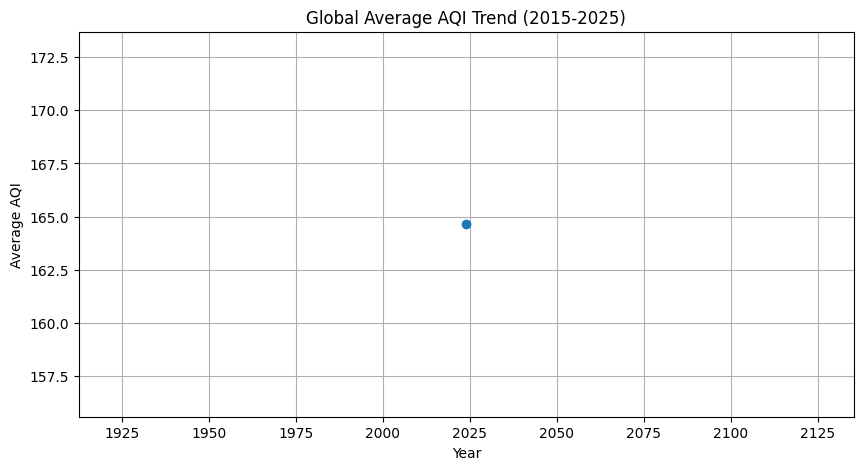

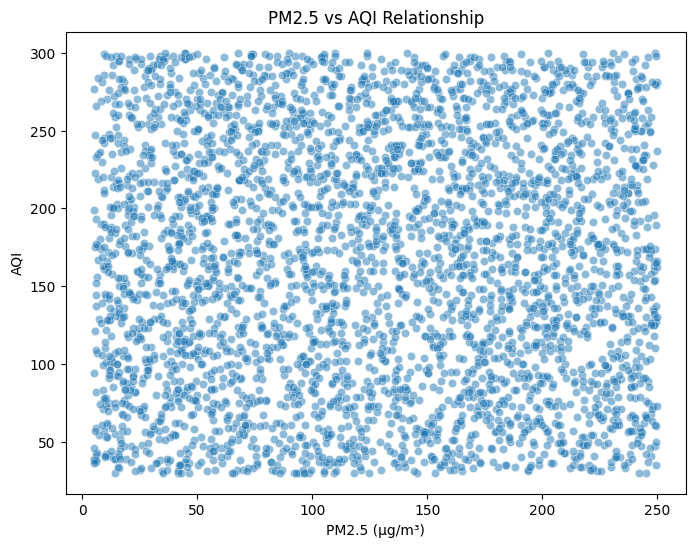

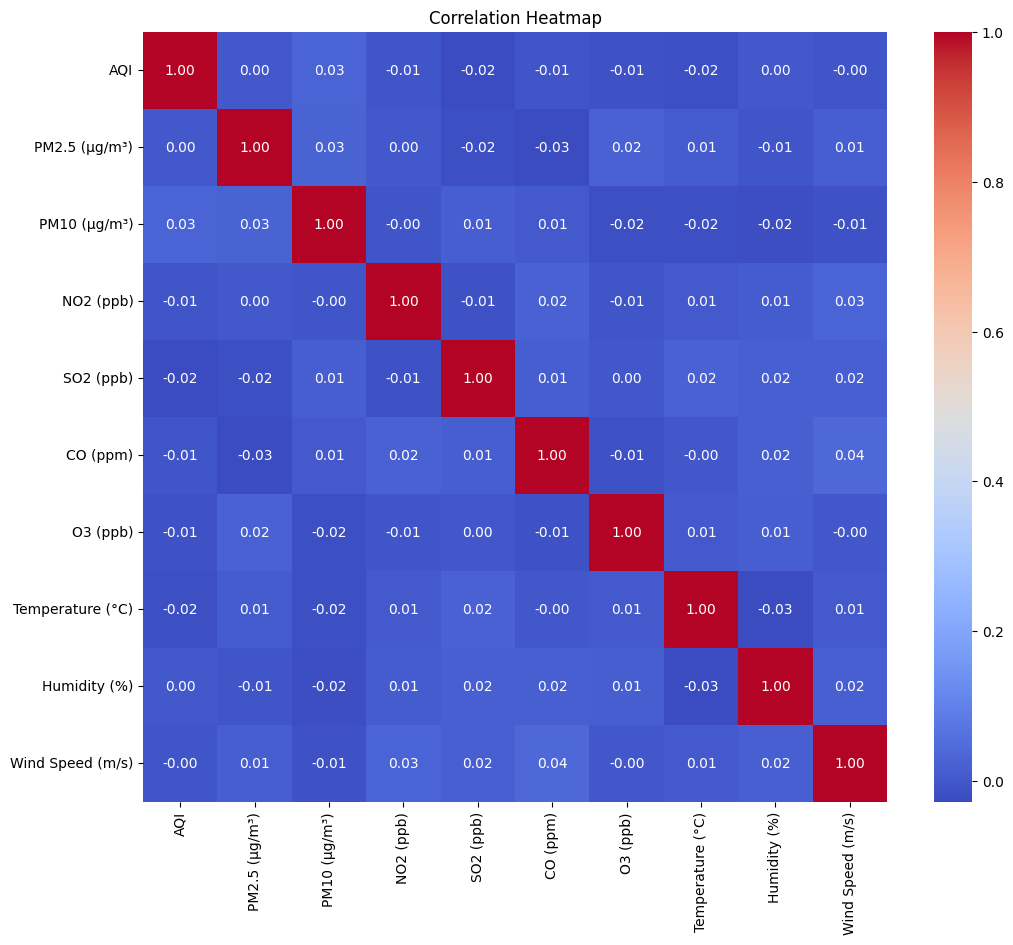

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Viz 1: AQI category distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='AQI Category', order=df['AQI Category'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Distribution of AQI Categories')
plt.show()

# Viz 2: Average AQI by Country (top 10 worst)
avg_aqi_country = df.groupby('Country')['AQI'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
avg_aqi_country.plot(kind='bar')
plt.title('Top 10 Countries with Highest Average AQI')
plt.ylabel('Average AQI')
plt.show()

# Viz 3: AQI trend by year
yearly_avg = df.groupby('Year')['AQI'].mean()
plt.figure(figsize=(10,5))
plt.plot(yearly_avg.index, yearly_avg.values, marker='o')
plt.title('Global Average AQI Trend (2015-2025)')
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.grid(True)
plt.show()

# Viz 4: PM2.5 vs AQI scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='PM2.5 (µg/m³)', y='AQI', alpha=0.5)
plt.title('PM2.5 vs AQI Relationship')
plt.show()

# Viz 5: Correlation heatmap (numeric columns only)
numeric_df = df[['AQI', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (ppb)', 'SO2 (ppb)',
                 'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)']]
plt.figure(figsize=(12,10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**Basic Statistics Table**

In [12]:
stats = {
    'Mean AQI': df['AQI'].mean(),
    'Minimum AQI': df['AQI'].min(),
    'Maximum AQI': df['AQI'].max(),
    'Standard Deviation': df['AQI'].std(),
    'Highest AQI City/Country': df.loc[df['AQI'].idxmax(), 'City'] + ', ' + df.loc[df['AQI'].idxmax(), 'Country'],
    'Lowest AQI City/Country': df.loc[df['AQI'].idxmin(), 'City'] + ', ' + df.loc[df['AQI'].idxmin(), 'Country']
}
for k, v in stats.items():
    print(f"{k}: {v}")

Mean AQI: 164.64207650273224
Minimum AQI: 30
Maximum AQI: 300
Standard Deviation: 78.57165923842541
Highest AQI City/Country: São Paulo, Brazil
Lowest AQI City/Country: Los Angeles, USA


**Part E & F – Supervised Learning (KNN & Naive Bayes)**

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Select numerical features (excluding non-numeric and target)
feature_cols = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (ppb)', 'SO2 (ppb)',
                'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)']
X = df[feature_cols].copy()
y = df['AQI Category']

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # Good=0, Moderate=1, etc.

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**KNN (k=3,5,7)**

In [14]:
k_values = [3,5,7]
best_k = None
best_acc = 0
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"k={k} Accuracy: {acc:.4f}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    if acc > best_acc:
        best_acc = acc
        best_k = k
print(f"\nBest k = {best_k} with accuracy {best_acc:.4f}")

k=3 Accuracy: 0.2077
[[ 6 16 10  4 27]
 [25 35 26  8 48]
 [20 23 20  9 42]
 [20 34 15 14 47]
 [48 79 47 32 77]]
                                precision    recall  f1-score   support

                          Good       0.05      0.10      0.07        63
                      Moderate       0.19      0.25      0.21       142
                     Unhealthy       0.17      0.18      0.17       114
Unhealthy for Sensitive Groups       0.21      0.11      0.14       130
                Very Unhealthy       0.32      0.27      0.29       283

                      accuracy                           0.21       732
                     macro avg       0.19      0.18      0.18       732
                  weighted avg       0.23      0.21      0.21       732

k=5 Accuracy: 0.2363
[[  2  11   9   9  32]
 [ 11  23  32  19  57]
 [ 14  18  25  14  43]
 [  8  26  26  16  54]
 [ 27  52  50  47 107]]
                                precision    recall  f1-score   support

                          G

**Naive Bayes**

In [15]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {acc_nb:.4f}")
print(confusion_matrix(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

Naive Bayes Accuracy: 0.3866
[[  0   0   0   0  63]
 [  0   0   0   0 142]
 [  0   0   0   0 114]
 [  0   0   0   0 130]
 [  0   0   0   0 283]]
                                precision    recall  f1-score   support

                          Good       0.00      0.00      0.00        63
                      Moderate       0.00      0.00      0.00       142
                     Unhealthy       0.00      0.00      0.00       114
Unhealthy for Sensitive Groups       0.00      0.00      0.00       130
                Very Unhealthy       0.39      1.00      0.56       283

                      accuracy                           0.39       732
                     macro avg       0.08      0.20      0.11       732
                  weighted avg       0.15      0.39      0.22       732



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Part G – K-Means Clustering (k=3)**


In [16]:
from sklearn.cluster import KMeans

# Prepare data for clustering (without target column)
X_cluster = df[feature_cols].copy()
# Remove any rows with missing values (none here)
X_cluster = X_cluster.dropna()

# Standardize
scaler_clust = StandardScaler()
X_cluster_scaled = scaler_clust.fit_transform(X_cluster)

# Apply K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_scaled)
X_cluster['Cluster'] = clusters

# Average AQI per cluster (need to align rows)
# Add AQI column to the same rows
X_cluster['AQI'] = df.loc[X_cluster.index, 'AQI']
X_cluster['PM2.5'] = df.loc[X_cluster.index, 'PM2.5 (µg/m³)']

# Summary table
cluster_summary = X_cluster.groupby('Cluster').agg({
    'AQI': 'mean',
    'PM2.5': 'mean'
}).round(2)
print(cluster_summary)

# Interpretation
cluster_summary['Interpretation'] = ['Low pollution', 'Medium pollution', 'High pollution']
print(cluster_summary)

            AQI   PM2.5
Cluster                
0        165.57  120.32
1        163.45  124.85
2        164.97  134.96
            AQI   PM2.5    Interpretation
Cluster                                  
0        165.57  120.32     Low pollution
1        163.45  124.85  Medium pollution
2        164.97  134.96    High pollution


**Part H – PCA Visualization**

Explained variance ratio: [0.12035055 0.1155008 ]
Total variance explained: 23.59%


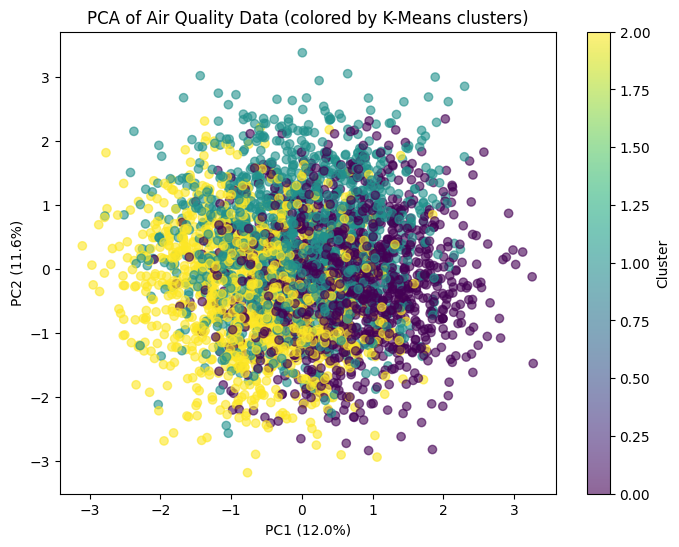

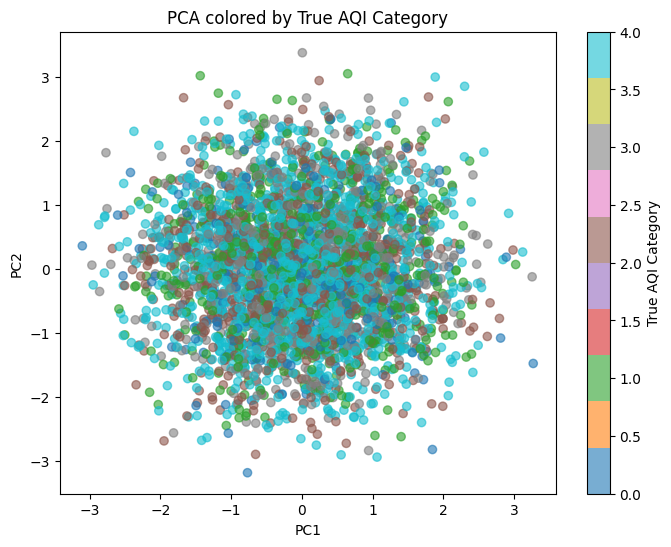

In [17]:
from sklearn.decomposition import PCA

# Use same scaled data (excluding cluster labels)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

# Explained variance
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

# Scatter plot colored by K-Means clusters
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('PCA of Air Quality Data (colored by K-Means clusters)')
plt.show()

# Optional: colored by true AQI Category
# Need to align y_true with X_cluster indices
y_true_cluster = le.transform(df.loc[X_cluster.index, 'AQI Category'])
plt.figure(figsize=(8,6))
scatter2 = plt.scatter(X_pca[:,0], X_pca[:,1], c=y_true_cluster, cmap='tab10', alpha=0.6)
plt.colorbar(scatter2, label='True AQI Category')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA colored by True AQI Category')
plt.show()